# Development

In [3]:
%load_ext autoreload
%autoreload 2

import os
ROOT_DIR = os.getcwd()[:os.getcwd().rfind('HEOM')]+ 'HEOM'
os.chdir(ROOT_DIR)

from heom import *
plt.style.use('heom-default')

import numpy as np 
import qutip as q
import matplotlib.pyplot as plt
import pandas as pd
import time

red, blue, orange, grey = '#B74244', '#459DD9', '#ED8532', '#A9ACBC'

## Params 1Q

In [4]:
import time 
t0 = time.time()

qc = QuantumCircuit(1)
qc.rx(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(0.5*np.pi, 0)
qc.delay(0, 0)
qc.ry(-0.5*np.pi, 0)

idlingTime = 0.1

rho = {'numQ': 1}
rho['rhoIni'] = np.array([[1, 0],
                          [0, 0]], dtype=np.complex128)
rho['omegaQ'] = [1.]

gateList = [[[0], 'rxyStep', ]]
kwargs1Q = {'omega': -rho['omegaQ'][0], 'gateTime': 0.1 * np.pi}
gateList = [[[0], 'rxyStep', kwargs1Q]]

bath = [{'type': 'broadband'}]
bath[0]['beta'] = 5
bath[0]['kappa'] = 0.004 / 2 / np.pi
bath[0]['omegaC'] = 50
bath[0]['exp'] = 1
bath[0]['tol'] = 1e-6

V = np.array([
    [[0, 1],
     [1, 0]]
], dtype=np.complex128)

dtFB = 0.001

strideTime = 0.01

stride = int(strideTime / dtFB)

depth = [2]
bondDim = 20

isRK13 = False
useRFPlus=False

if useRFPlus:
    depth  = [1] * len(depth)

In [5]:
nu = []
coeff = []
for i in range(rho['numQ']):
    nuTmp, coeffTmp = getBathParams(bath[i])
    
    nu.append(nuTmp)
    coeff.append(coeffTmp)
nu, coeff

C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\heom\bath\broadband.py:25: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))


([array([-663.62214027-3.17545616e+01j, -273.0475837 -3.03799312e+01j,
         -131.02678633-2.63154208e+01j,  -71.26005861-2.25862065e+01j,
          -45.77008161-1.66830850e+01j,  -31.40883724-8.35735589e+00j,
          -19.66613893-2.77851214e+00j,  -11.57382735-8.55848345e-01j,
           -6.7581818 -3.08176482e-01j,   -4.07346547-9.72563557e-02j,
           -2.52479727-8.86779993e-03j,   -1.25664559-4.02746375e-05j])],
 [array([-9.27929493e-03+1.36622743e-03j, -4.20168233e-02+1.44606402e-02j,
         -1.52101920e-01+1.21361231e-01j,  1.03617362e-02+7.67500287e-01j,
          1.30878742e+00-9.45518416e-02j, -8.67420773e-02-6.96087321e-01j,
         -1.57327932e-01-9.88769680e-02j, -5.06054378e-02-1.25181545e-02j,
         -1.59012765e-02-2.10990041e-03j, -5.11525787e-03-5.17314679e-04j,
         -2.11536232e-03-5.84160720e-05j, -1.00667344e-03-2.79357701e-07j])])

In [6]:
pulse, pulseMap = setGates(gateList)
pulse, pulseMap

([[[0], <heom.pulse.rxy_step.rxyStep at 0x20445da6c10>]], {(np.int64(0),): 0})

In [7]:
if rho['numQ'] == 1:
    TTs = TTs1Q(rho['rhoIni'], bondDim, V, depth, nu, coeff,
                pulse, pulseMap)
elif rho['numQ'] == 2:
    TTs = TTs2QId(rho['rhoIni'], bondDim, V, depth, nu, coeff,
                  pulse, pulseMap)
elif rho['numQ'] >= 3:
    TTs = TTsMQChainId(rho['numQ'], rho['rhoIni'], bondDim, V, depth,
                       nu, coeff, pulse, pulseMap)

TTs

In [8]:
TTs.__dict__

{'numQ': 1,
 'numCore': 26,
 'numH': 4,
 'dim': [12],
 'ptrKet': [0],
 'ptrBra': [25],
 'rho': [zTT(core=array([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]), level=np.int64(2), bondDimL=1, bondDimR=np.int64(2)),
  zTT(core=array([1.-0.j, 0.-0.j, 0.-0.j, 1.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j]), level=np.int64(3), bondDimL=2, bondDimR=6),
  zTT(core=array([1.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 1.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 1.-0.j, 0.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 1.-0.j, 0.-0.j, 0.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 1.-0.j, 0.-0.j, 0.-0.j, 0.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 1.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j,
         0.-0.j, 0.-0.j, 0.-0.j, 0.-0.

In [9]:
setPulseSeq(qc, TTs, rho['omegaQ'], dtFB, idlingTime)

In [16]:
qcTransformed = transform(qc, TTs)
qcTransformed.draw()

┌──────────────────┐┌──────────────┐┌─────────────┐┌──────────────┐»
q ┤ U3(π/2,-π/2,π/2) ├┤ Delay(0[dt]) ├┤ U3(π/2,0,0) ├┤ Delay(0[dt]) ├»
  └──────────────────┘└──────────────┘└─────────────┘└──────────────┘»
«  ┌──────────────┐
«q ┤ U3(-π/2,0,0) ├
«  └──────────────┘

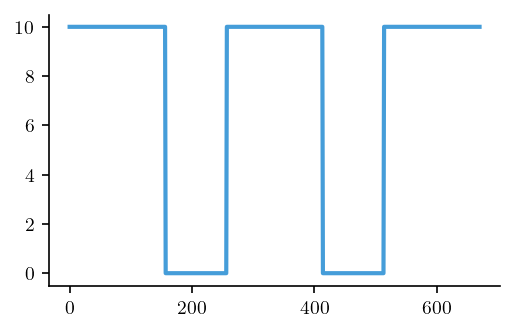

In [13]:
fig, ax = plt.subplots()

ax.plot( TTs.pulse[0][1].ampSeq )

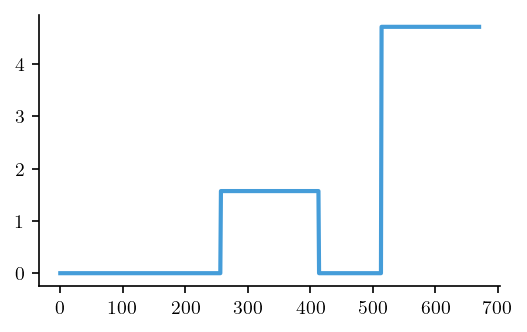

In [12]:
fig, ax = plt.subplots()

ax.plot( TTs.pulse[0][1].phaseSeq )

## Parmams 3Q

In [58]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
# qc.ccx(0, 1, 2)

idlingTime = 0 # 0.005

rho = {'numQ': 3}
rhoIni = np.zeros([8, 8], dtype=np.complex128)
rhoIni[0, 0] = 1
rho['rhoIni'] = rhoIni

rho['omegaQ'] = [1., 1., 1.] # in the order: [qubit 2, qubit 1, qubit 0]

kwargs1Q = [{'omega': -rho['omegaQ'][2], 'gateTime': 0.1},
            {'omega': -rho['omegaQ'][1], 'gateTime': 0.1},
            {'omega': -rho['omegaQ'][0], 'gateTime': 0.1},]

kwargs2Q = {'gateTime': 0.05}

gateList = [[[0], 'rxyStep', kwargs1Q[0]],
            [[1], 'rxyStep', kwargs1Q[1]],
            [[2], 'rxyStep', kwargs1Q[2]],
            [[0, 1], 'directCplStepVarJ', kwargs2Q],
            [[1, 2], 'directCplStepVarJ', kwargs2Q],]

bathParams = {'type': 'broadband'}
bathParams['beta'] = 5
bathParams['kappa'] = 0.004 / 2 / np.pi
bathParams['omegaC'] = 50
bathParams['exp'] = 1
bathParams['tol'] = 1e-6

bath = [bathParams, bathParams, bathParams] 
# in the order: [qubit 2, qubit 1, qubit 0]

V = np.array([
    [[0, 1],
     [1, 0]],

    [[0, 1],
     [1, 0]],

    [[0, 1],
     [1, 0]]
], dtype=np.complex128) # in the order: [qubit 2, qubit 1, qubit 0]

dtFB = 0.001

strideTime = 0.01

stride = int(strideTime // dtFB)

depth = [2, 2, 2]
bondDim = 20

isRK13 = False
useRFPlus=True

if useRFPlus:
    depth  = [1] * len(depth)

In [32]:
nu = []
coeff = []
for i in range(rho['numQ']):
    nuTmp, coeffTmp = getBathParams(bath[i])
    
    nu.append(nuTmp)
    coeff.append(coeffTmp)
nu, coeff

([array([-663.62214027-3.17545616e+01j, -273.0475837 -3.03799312e+01j,
         -131.02678633-2.63154208e+01j,  -71.26005861-2.25862065e+01j,
          -45.77008161-1.66830850e+01j,  -31.40883724-8.35735589e+00j,
          -19.66613893-2.77851214e+00j,  -11.57382735-8.55848345e-01j,
           -6.7581818 -3.08176482e-01j,   -4.07346547-9.72563557e-02j,
           -2.52479727-8.86779993e-03j,   -1.25664559-4.02746375e-05j]),
  array([-663.62214027-3.17545616e+01j, -273.0475837 -3.03799312e+01j,
         -131.02678633-2.63154208e+01j,  -71.26005861-2.25862065e+01j,
          -45.77008161-1.66830850e+01j,  -31.40883724-8.35735589e+00j,
          -19.66613893-2.77851214e+00j,  -11.57382735-8.55848345e-01j,
           -6.7581818 -3.08176482e-01j,   -4.07346547-9.72563557e-02j,
           -2.52479727-8.86779993e-03j,   -1.25664559-4.02746375e-05j]),
  array([-663.62214027-3.17545616e+01j, -273.0475837 -3.03799312e+01j,
         -131.02678633-2.63154208e+01j,  -71.26005861-2.25862065e+01j,
  

In [59]:
pulse, pulseMap = setGates(gateList)
pulse, pulseMap

([[[0], <heom.pulse.rxy_step.rxyStep at 0x2044bed2590>],
  [[1], <heom.pulse.rxy_step.rxyStep at 0x2044bed2a10>],
  [[2], <heom.pulse.rxy_step.rxyStep at 0x2044bed3710>],
  [[0, 1],
  [[1, 2],
 {(np.int64(0),): 0,
  (np.int64(1),): 1,
  (np.int64(2),): 2,
  (np.int64(0), np.int64(1)): 3,
  (np.int64(1), np.int64(2)): 4})

In [60]:
if rho['numQ'] == 1:
    TTs = TTs1Q(rho['rhoIni'], bondDim, V, depth, nu, coeff,
                pulse, pulseMap)
elif rho['numQ'] == 2:
    TTs = TTs2QId(rho['rhoIni'], bondDim, V, depth, nu, coeff,
                  pulse, pulseMap)
elif rho['numQ'] >= 3:
    TTs = TTsMQChainId(rho['numQ'], rho['rhoIni'], bondDim, V, depth,
                       nu, coeff, pulse, pulseMap)

TTs

In [64]:
setPulseSeq(qc, TTs, rho['omegaQ'], dtFB, idlingTime)

In [65]:
numQubits = qc.num_qubits
qcTransformed = transform(qc, TTs)
qcTransformed.draw()

┌─────────────┐   ┌─────────┐┌─────────────┐┌─────────┐»
q_0 -> 0 ──┤ U3(π/2,0,π) ├───┤0        ├┤ U3(π/2,0,0) ├┤0        ├»
         ┌─┴─────────────┴──┐│  iswapd │└─────────────┘│  iswapd │»
q_1 -> 1 ┤ U3(π/2,-π/2,π/2) ├┤1        ├───────────────┤1        ├»
         └──────────────────┘└─────────┘               └─────────┘»
«         ┌──────────────┐
«q_0 -> 0 ┤ U3(0,0,-π/2) ├
«         └┬───────────┬─┘
«q_1 -> 1 ─┤ U3(0,0,π) ├──
«          └───────────┘

In [63]:
# apply virtual-Z-gate schemes
qcVZ = QuantumCircuit(numQubits)
globalPhase = 0
localPhase = [0] * numQubits
for gate in qcTransformed.data:
    if gate.name != 'delay':
        params = list(gate.operation.params)
        params.append(gate.operation.name)
        qubitIdx = list(np.sort([q._index for q in gate.qubits]))
        pulseIdx = TTs.map[tuple(qubitIdx)]
        gateOut, globalPhase, localPhase = \
            TTs.pulse[pulseIdx][1].vzTransform(
                params, globalPhase, localPhase, qubitIdx
            )
    else:
        gateOut = gate.operation

    qcVZ.append(gateOut, qubitIdx)

qcVZ.global_phase = globalPhase

qcVZ.draw()

global phase: 3π/4
       ┌──────────────┐  ┌─────────┐┌─────────────┐┌─────────┐»
q_0: ──┤ U3(π/2,-π,π) ├──┤0        ├┤ U3(π/2,0,0) ├┤0        ├»
     ┌─┴──────────────┴─┐│  iswapd │└─────────────┘│  iswapd │»
q_1: ┤ U3(π/2,-π/2,π/2) ├┤1        ├───────────────┤1        ├»
     └──────────────────┘└─────────┘               └─────────┘»
q_2: ─────────────────────────────────────────────────────────»
                                                              »
«     ┌────────────────┐
«q_0: ┤ U3(0,-π/2,π/2) ├
«     └─┬────────────┬─┘
«q_1: ──┤ U3(0,-π,π) ├──
«       └────────────┘  
«q_2: ──────────────────
«

In [78]:
# set gate time for each gate and insert idling
idlingStep = int(idlingTime / dtFB)
qcWithDelay = QuantumCircuit(numQubits)
tgt = Target(dt=1)
deltaT = Parameter('deltaT')
tgt.add_instruction(Delay(deltaT))

for i, gate in enumerate(qcVZ.data):
    qubitIdx = list(np.sort([q._index for q in gate.qubits]))
    params = gate.operation.params
    if gate.name != 'delay':
        name = f'g{i}'
        pulseIdx = TTs.map[tuple(qubitIdx)]
        dur = TTs.pulse[pulseIdx][1].getGateTime(dtFB, params)
        params = [dur] + params
        
        if len(qubitIdx) == 2:
            gateTmp = Instruction(name, 2, 0, params)
        else:
            gateTmp = Instruction(name, 1, 0, params)

        qcWithDelay.append(gateTmp, qubitIdx)

        if TTs.pulse[pulseIdx][1].isDelayed(gate.operation.name):
            qcWithDelay.delay(idlingStep, qubitIdx)
        

        prop = {tuple(qubitIdx): InstructionProperties(duration=dur)}
        tgt.add_instruction(gateTmp, prop)
    else:
        qcWithDelay.delay(params[0], qubitIdx)

qcScheduled = scheduling(qcWithDelay)
qcScheduled.draw()

┌─────────────────┐  ┌──────────────┐┌─────────┐ ┌──────────────┐»
q_0: ──┤ g0(50,π/2,-π,π) ├──┤ Delay(0[dt]) ├┤0        ├─┤ Delay(0[dt]) ├»
     ┌─┴─────────────────┴─┐├──────────────┤│  g2(50) │┌┴──────────────┤»
q_1: ┤ g1(50,π/2,-π/2,π/2) ├┤ Delay(0[dt]) ├┤1        ├┤ Delay(50[dt]) ├»
     └──┬────────────────┬─┘└──────────────┘└─────────┘└───────────────┘»
q_2: ───┤ Delay(200[dt]) ├──────────────────────────────────────────────»
        └────────────────┘                                              »
«     ┌────────────────┐┌──────────────┐┌─────────┐┌──────────────┐»
«q_0: ┤ g3(50,π/2,0,0) ├┤ Delay(0[dt]) ├┤0        ├┤ Delay(0[dt]) ├»
«     └┬──────────────┬┘└──────────────┘│  g4(50) │├──────────────┤»
«q_1: ─┤ Delay(0[dt]) ├─────────────────┤1        ├┤ Delay(0[dt]) ├»
«      └──────────────┘                 └─────────┘└──────────────┘»
«q_2: ─────────────────────────────────────────────────────────────»
«                                                                  »
«     ┌──────────────────┐┌──────────────┐
«q_0: ┤ g5(0,0,-π/2,π/2) ├┤ Delay(0[dt]) ├
«     └─┬──────────────┬─┘├──────────────┤
«q_1: ──┤ g6(0,0,-π,π) ├──┤ Delay(0[dt]) ├
«       └──────────────┘  └──────────────┘
«q_2: ────────────────────────────────────
«

In [80]:
totalSize = qcScheduled.estimate_duration(tgt, 'dt')
totalSize

200

In [88]:
TTs.pulse[0][1].getPrefactor(dt, time, stepNum)

array([31.41592654, 31.41592654, 31.41592654, ...,  0.        ,
        0.        ,  0.        ], shape=(2500,))

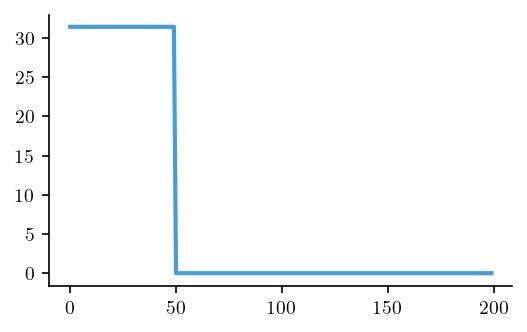

In [76]:
fig, ax = plt.subplots()

ax.plot( TTs.pulse[1][1].ampSeq )

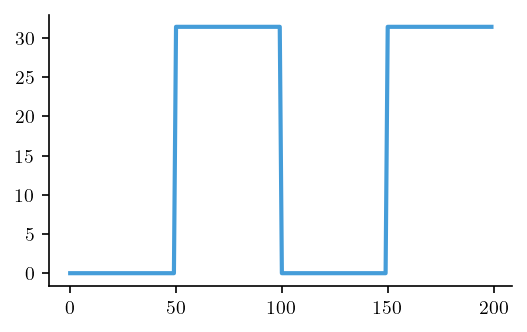

In [77]:
fig, ax = plt.subplots()

ax.plot( TTs.pulse[3][1].JSeq )

In [2]:
TensorHeomApp().mainloop()

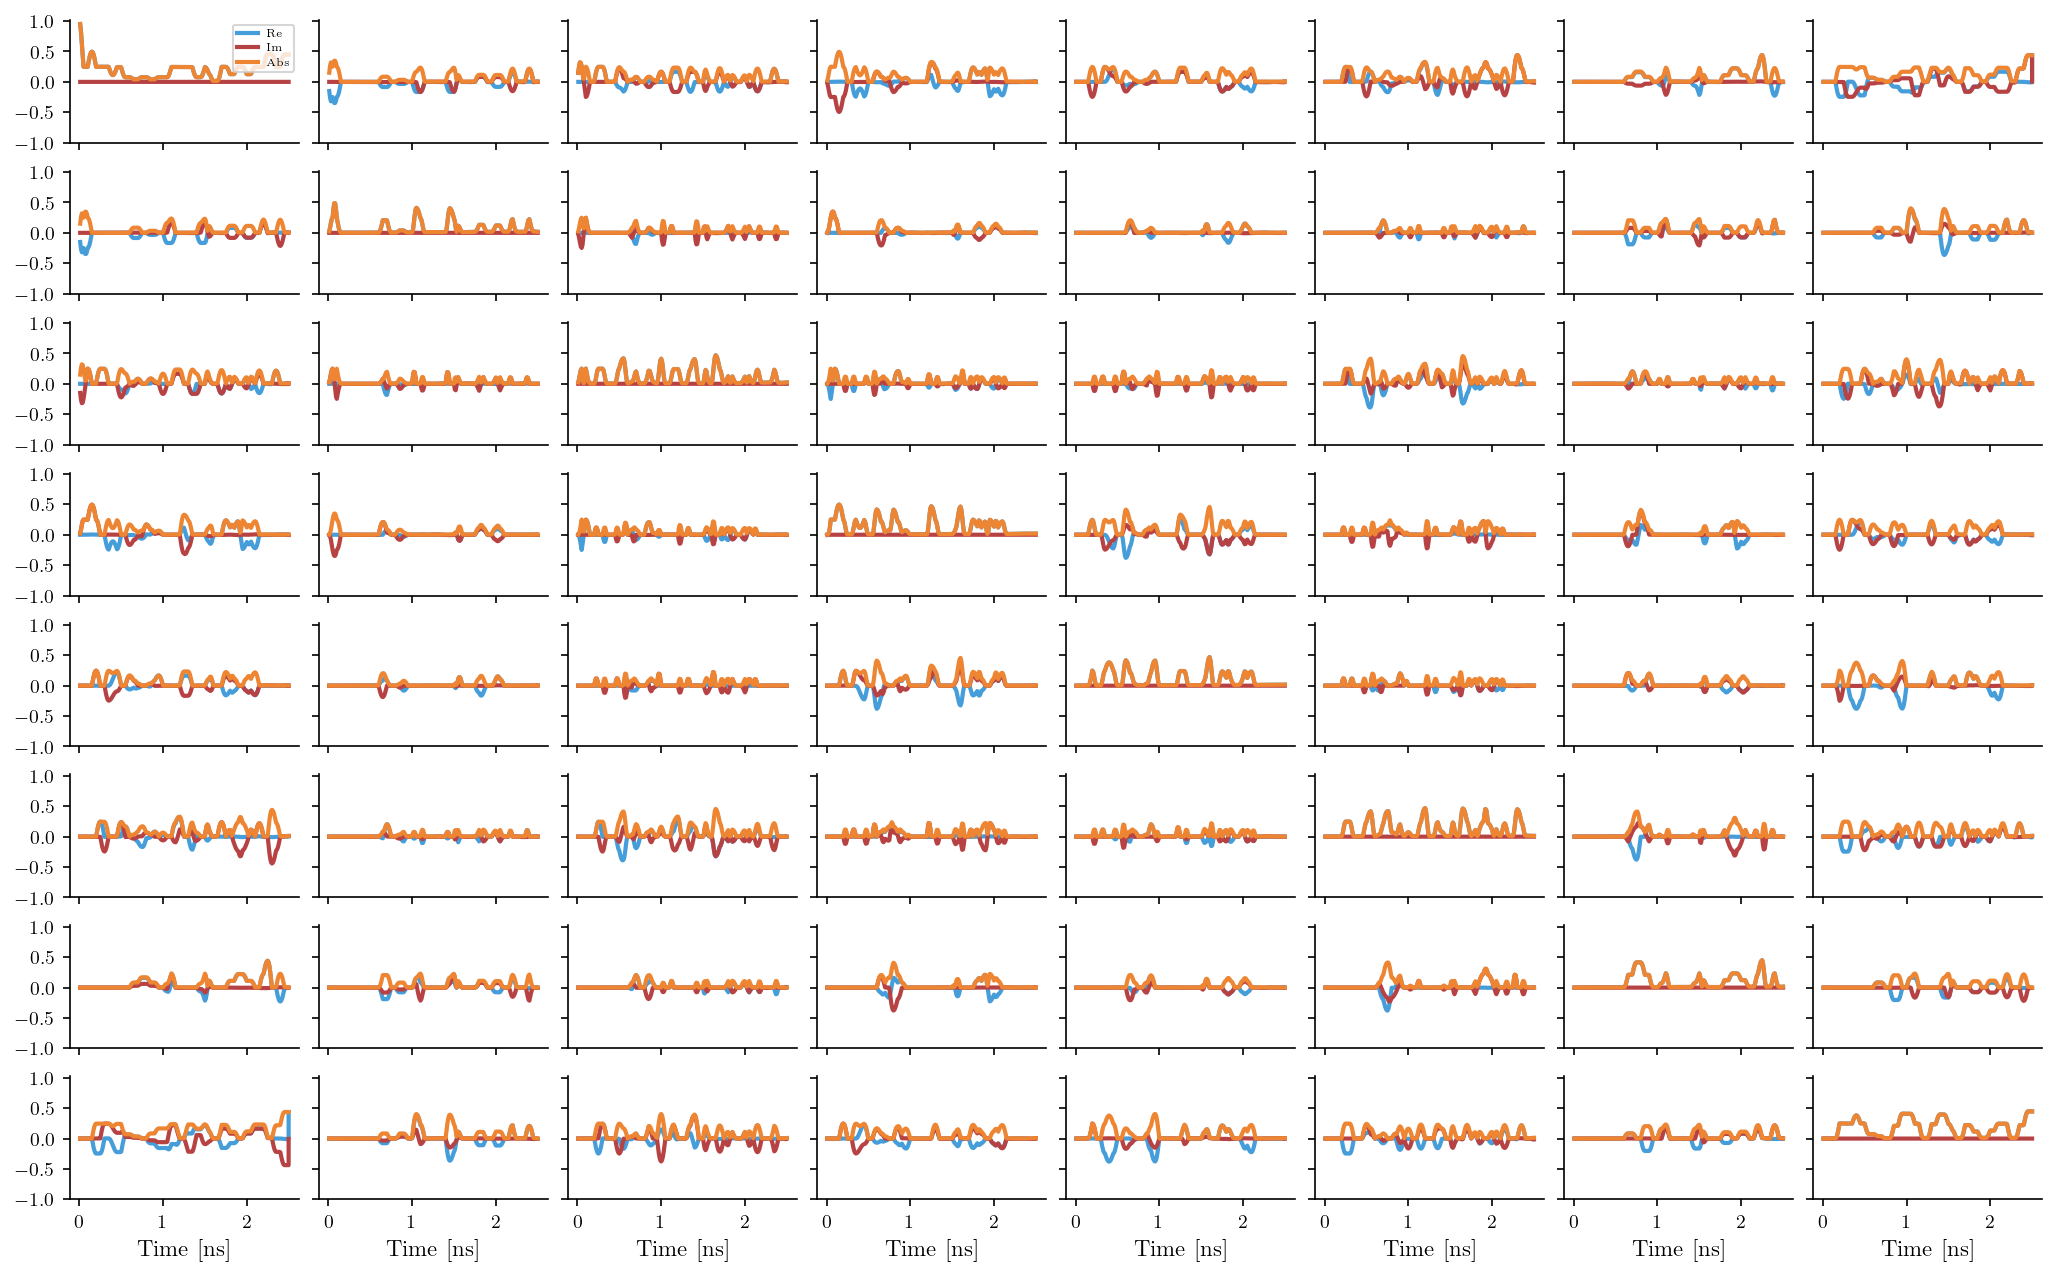

In [13]:
t_list, dm_list = load_density_matrices("19404542.csv")

dim = dm_list[0].shape[0]
fig, ax = plt.subplots(dim, dim, figsize=(dim*1.7, dim*1.05), sharex=True, sharey=True)
for i in range(dim):
    for j in range(dim):
        ax[i,j].plot(t_list, [dm[i,j].real for dm in dm_list])
        ax[i,j].plot(t_list, [dm[i,j].imag for dm in dm_list])
        ax[i,j].plot(t_list, [np.abs(dm[i,j]) for dm in dm_list])

        ax[i,j].set_yticks([-1, -0.5, 0, 0.5, 1])
for j in range(dim):
    ax[-1,j].set_xlabel("Time [ns]")
ax[0,0].legend(['Re', 'Im', 'Abs'], loc='upper right', fontsize=5)